
# fix the intial loss
initially, the ouput should be equally, i.e. all characters should have
same probability as the next character, i.e. 1 / 27

which means the parametes (C, W1, b1, W2, b2) should be set in certain way so that
the logits / output layer's activation should all be equal, e.x. 0. 

since `logits = h @ W2 + b2`, we can set `b2 = 0` and `W2` to very small number, like 0.01

# fix the saturated tanh
intially the the hidden layer, after applying tanh, is saturated, i.e. quite some activation
of the hidden layer lays at near -1 or 1, which make them `dead neurons`. Because accoding to
the backward propagation rule, if `t` is near -1 or 1, the neuron will not learn anything:

`self.grad += (1 - t**2) * out.grad`

how to fix?

we do not want many saturated hidden neurons ->
we want the `hpreact` to be distributd in a smaller range around 0 ->
`hpreact = embcat @ W1 + b1` ->
let `b1 = 0` and set `W1` to small number

# kaiming init

# batch normalization
side effect: inputs in one batch are now not indepedent; the inputs in a batch couples, 
logits gets jitter, but have regularizing effects

Q: now the neural network expects inputs in batches, how to calcualte the result of a single
training data?

A:

1. calibrate the batch norm at the end of training, add one more stage

2. running calculation

# Py-torch fying the code


In [269]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt     # for making figures
%matplotlib inline

In [270]:
# read all the words
words = open('../name.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [271]:
len(words)

32033

In [272]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(set(''.join(words)))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [273]:
# build the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]    # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1 : n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [274]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backpro)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a sunning 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculcate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True)   # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)    # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [275]:
n_emb = 10  # the demensionality of the character embedding vectors
n_hidden = 100  # the number of the neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)   # for reproducibility

C = torch.randn((vocab_size, n_emb),             generator=g)
layers = [
    Linear(n_emb * block_size, n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), Tanh(),
    Linear(          n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: appy gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

46497


In [276]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]   # batch X, Y

    # forward pass
    emb = C[Xb]     # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss functions

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01    # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000:
        break   # AFTER_DEBUG: take out break to run full optimization

      0/ 200000: 3.2962


layer 0 (    Linear): mean -0.16, std 1.69 saturated: 57.81%
layer 2 (    Linear): mean +0.00, std 1.36 saturated: 49.97%
layer 4 (    Linear): mean +0.01, std 1.47 saturated: 54.94%
layer 6 (    Linear): mean -0.07, std 1.41 saturated: 53.78%
layer 8 (    Linear): mean -0.02, std 1.32 saturated: 47.53%


Text(0.5, 1.0, 'activation distribution')

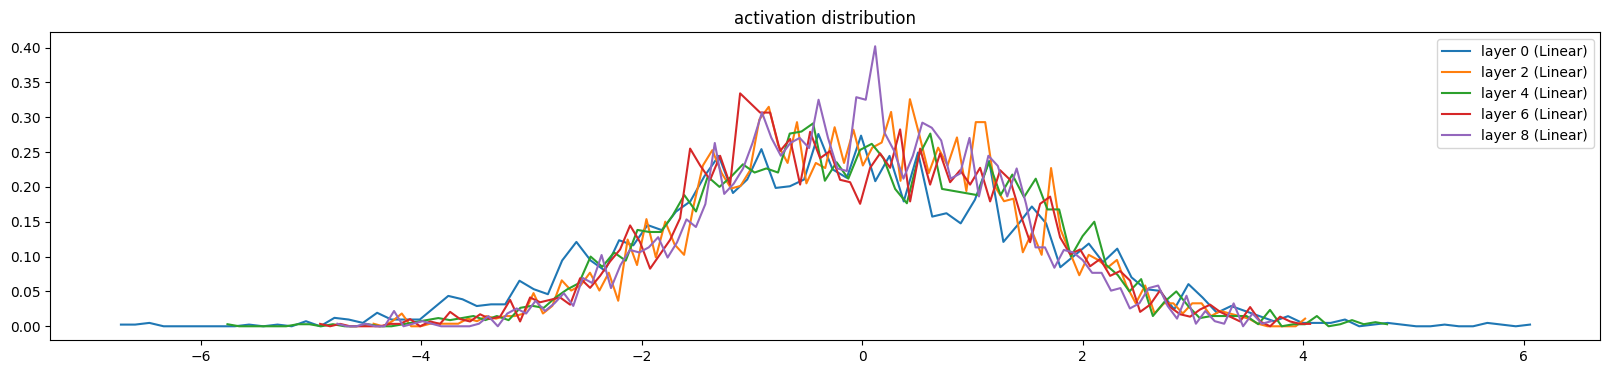

In [277]:
# visualize the activation
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Linear):
        t = layer.out.detach()
        print('layer %d (%10s): mean %+.2f, std %.2f saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 0 (    Linear): mean -0.000009, std 1.654044e-03
layer 2 (    Linear): mean -0.000012, std 1.776458e-03
layer 4 (    Linear): mean -0.000013, std 1.627171e-03
layer 6 (    Linear): mean +0.000008, std 1.527207e-03
layer 8 (    Linear): mean +0.000005, std 1.321947e-03


Text(0.5, 1.0, 'gradient distribution')

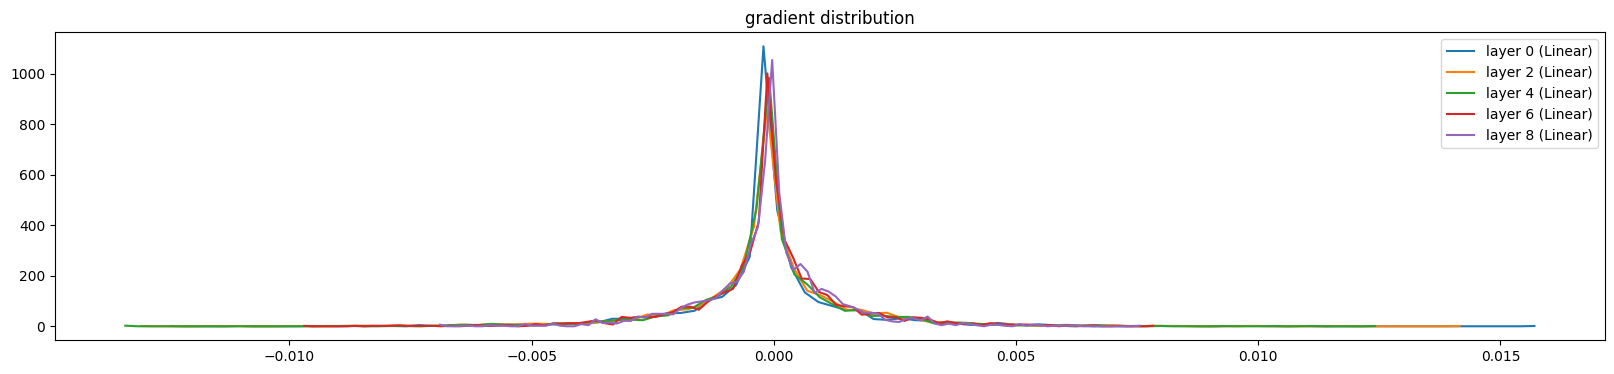

In [278]:
# visualize the gradient
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Linear):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000772 | std 9.714626e-03 | grad:data ratio 9.714512e-03
weight  (30, 100) | mean -0.000036 | std 8.734052e-03 | grad:data ratio 2.792837e-02
weight (100, 100) | mean +0.000085 | std 7.424630e-03 | grad:data ratio 4.417373e-02
weight (100, 100) | mean +0.000055 | std 6.242014e-03 | grad:data ratio 3.681917e-02
weight (100, 100) | mean +0.000007 | std 6.161664e-03 | grad:data ratio 3.650616e-02
weight (100, 100) | mean +0.000069 | std 5.221999e-03 | grad:data ratio 3.102274e-02
weight  (100, 27) | mean -0.000000 | std 2.281147e-02 | grad:data ratio 3.229574e-01


Text(0.5, 1.0, 'weights gradient distribution')

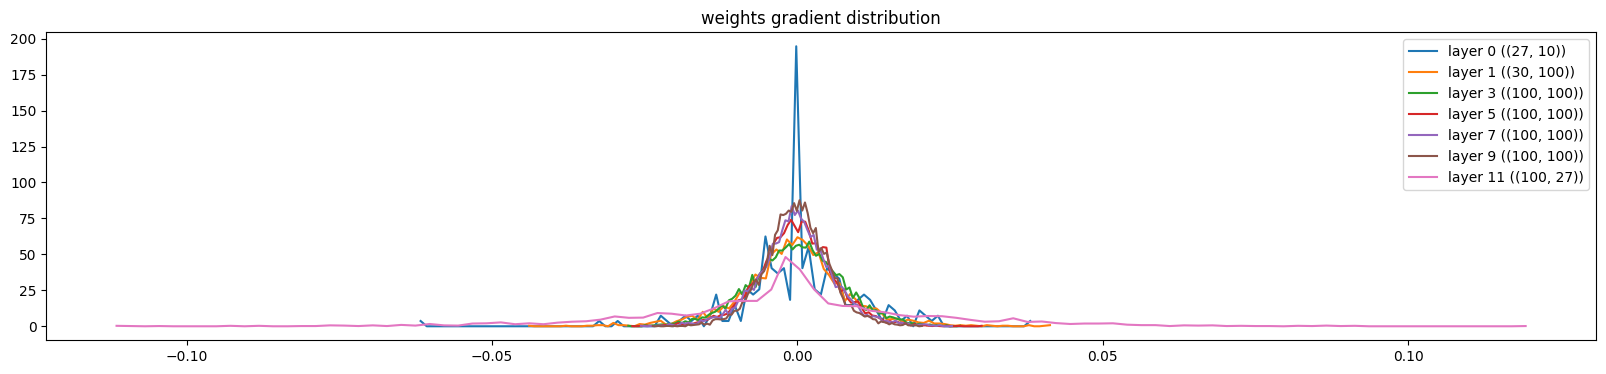

In [279]:
# visualize the gradient
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:     # skipp bias, gamma and beta, for simplicity reason
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std())) 
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({tuple(p.shape)})')
plt.legend(legends)
plt.title('weights gradient distribution')

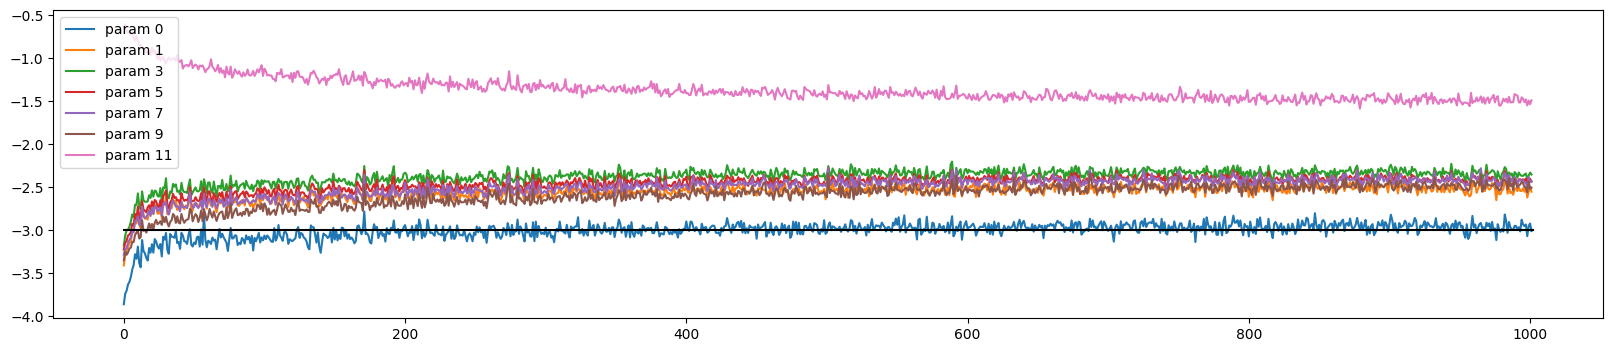

In [281]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k')   # these ratios sould be ~1e-3, indicate on plot
plt.legend(legends)

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_emb)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)    # (N, n_hidden)
    logits = h @ W2 + b2    # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.4318201541900635
val 2.437371253967285


In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]    # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

carpzvramilllvifn.
mlsirestlfsalaysie.
rahnkliam.
santhvgqhib.
raysia.
chmiir.
briefmadhlthn.
bruqxinnnshltnrilivdnq.
wazell.
diarisimfrydenits.
bruy.
bdii.
brileshdus.
darsas.
bustncsyn.
saqqwiozelyzotrmiyra.
day.
dep.
sadluuo.
zoess.
